<a href="https://colab.research.google.com/github/nicecoconuts2/Evan_INFO4670_Spring2026/blob/main/Logistic_Regression_Car_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 11: Assignment 4 - Logistic Regression Assignment (Age & Salary → Purchased)
**Coures:** INFO 4670 Fengjiao Tu  
**Goal:** Train and evaluate a Logistic Regression model to predict whether a customer purchases a car using `Age` and `Salary`.

---

## I. Assignment Objective
By completing this assignment, you will:
- Understand the concept and intuition of logistic regression.
- Load and preprocess data using `pandas`.
- Train and evaluate a logistic regression model with `scikit-learn`.
- Visualize classification results.
- Analyze model performance and reflect on possible improvements.


## II. Dataset Description
Expected CSV file name: **`car_purchase_data.csv`**

| Column | Description | Example |
|--------|-------------|---------|
| `Age` | Age of the customer | 35 |
| `Salary` | Annual or monthly income | 60000 |
| `Purchased` | Whether the customer purchased a car (1 = Yes, 0 = No) | 1 |


---
# Grading Rubric (Total = 100 points)

| Section | Description | Points | Details |
|--------|-------------|--------|---------|
| **Objective Understanding** | Explain purpose and logic of logistic regression | 10 | Goal & rationale (5); why LR for this task (5) |
| **Data Preparation** | Data loading, splitting, scaling | 20 | Import & preview (5); X/y split (5); train/test (5); scaling (5) |
| ** Model Training & Evaluation** | Fit, predict, metrics, visualization | 40 | Trained correctly (10); metrics shown (10); **accuracy ≥ 87.5% (10)**; visualization (10) |
| ** Analysis & Reflection** | Interpretation and critical thinking | 30 | Probability→class explanation (10); result discussion (10); improvements (10) |


**Accuracy Requirement:**
- Full credit (10 pts) if **accuracy ≥ 87.5%**
- Partial (7–9 pts) if **80% ≤ accuracy < 87.5%**
- Minimal (≤5 pts) if **accuracy < 80%**
- 0 pts if the model fails to run


## III. Steps to Complete
Follow the cells below in order. According to the hands-on task, please complete the code.

### Step 1: Import libraries and load data

In [10]:
#Please write the code here
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
#load dataset
df = pd.read_csv('car_purchase_data.csv')

#preview dataset
df.head()

,User ID,Gender,Age,Salary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


### Step 2: Split features and target

In [11]:
#Please write the code here
#features (only Age and Salary)
X = df[['Age', 'Salary']]
#target
y = df['Purchased']
#show shapes to confirm
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (400, 2)
y shape: (400,)


### Step 3: Train/Test Split

In [12]:
#Please write the code here
#split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=0
)
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (300, 2)
X_test: (100, 2)
y_train: (300,)
y_test: (100,)


### Step 4: Feature Scaling

In [13]:
#Please write the code here
#feature Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### Step 5: Train Logistic Regression Model

In [14]:
#Please write the code here
#train Logistic Regression model
model = LogisticRegression()

model.fit(X_train, y_train)

LogisticRegression()

### Step 6: Predict and Evaluate

In [15]:
#Please write the code here
#predict on test data
y_pred = model.predict(X_test)

#accuracy
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)

#confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

Accuracy: 0.89
Confusion Matrix:
[[65  3]
 [ 8 24]]


### Step 7: Visualization of Decision Regions

/tmp/ipykernel_267/50469117.py:20: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(


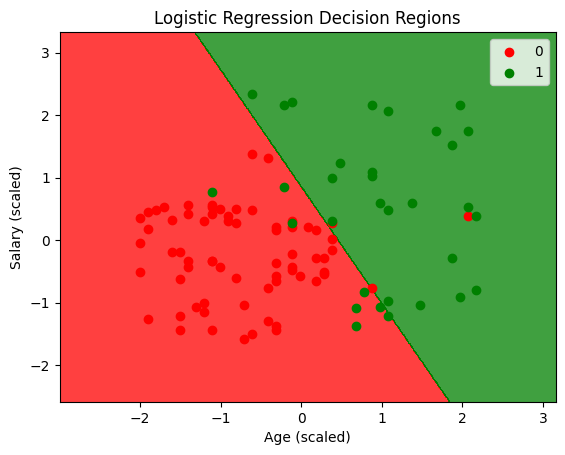

In [19]:
#Please write the code here
from matplotlib.colors import ListedColormap

X_set, y_set = X_test, y_test

X1, X2 = np.meshgrid(
    np.arange(start = X_set[:, 0].min() - 1, stop = X_set[:, 0].max() + 1, step = 0.01),
    np.arange(start = X_set[:, 1].min() - 1, stop = X_set[:, 1].max() + 1, step = 0.01)
)
plt.contourf(
    X1, X2,
    model.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
    alpha = 0.75,
    cmap = ListedColormap(('red', 'green'))
)
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())

for i, j in enumerate(np.unique(y_set)):
    plt.scatter(
        X_set[y_set == j, 0],
        X_set[y_set == j, 1],
        c = ListedColormap(('red', 'green'))(i),
        label = j
    )
plt.title('Logistic Regression Decision Regions')
plt.xlabel('Age (scaled)')
plt.ylabel('Salary (scaled)')
plt.legend()
plt.show()

## IV. Reflection Questions
1. Logistic regression outputs probabilities — why can it still be used for classification?
2. Based on your model, which customers are more likely to purchase a car?
3. What factors might cause low accuracy in this task?
4. Propose additional features or preprocessing steps that could improve accuracy.


#Please write your answer here

1. We can produce a probability value between 0 and 1 with logistic regression if we use the sigmoid function. With this probability we can deduce how likely an observation belongs to a particuclar class. When doing classification tasks the threshold is typicall 0.5, and is used to convert the probability into a class label. If our predicted proability is greater than or equal to the threshold, then the model assigns the observation to class 1, in other cases it's assigned to 0. This allows logistic regression to function as a classification model despite the fact it outputs probabilities.

2. Customers with higher salaries and slightly older ages are more likely to purhcase a car. A linear decision boundary helps to seperate customers who purhcased from the ones that didn't. There is a higher predicted probability of pruchasing for customers who fell into the region associated with higher income levels and moderate to higher age ranges.

3. Low accuracy can occur because of overlapping feature ditributions between customers who purchase and those who do not. Age and salary alone do not fully explain  the purhcasing behavior, so the model may struggle to seperate the classes. Noise in the data, outliers and insufficient training samples can also negatively impact the performance. If the relationship between freatures and the target bariable happens to be nonlinear, logisticf regression might not be able to capture it effectively.

4. We can potentially improve accuracy by including additional features that are relevant like customer education level, credit score, marital status, and previous purchase history and geographic location. We can take steps to preprocess, like outlier removal, feature engineering, cross-validation and hyperparamter tuning. If we use more advanced models we could possible capture nonlinear patterns that can furhter improve classifcation accuracy.